# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abbas-707/FlyRank-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)



In [1]:
!git clone https://github.com/abbas-707/FlyRank-Internship.git
%cd FlyRank-Internship

Cloning into 'FlyRank-Internship'...
remote: Enumerating objects: 158, done.
remote: Counting objects: 100% (158/158), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 158 (delta 64), reused 92 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (158/158), 1.90 MiB | 11.16 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/FlyRank-Internship


In [2]:
import duckdb
from google.colab import userdata
import pandas as pd
import numpy as np
import os, json

hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.sql(f"CREATE SECRET hf_token (TYPE huggingface, TOKEN '{hf_token}');")

┌─────────┐
│ Success │
│ boolean │
├─────────┤
│ true    │
└─────────┘

## 1. Question

**Lane: Refresh / Content Opportunity Scoring.**

Which pages should a content team review first — flagged by a measured gap between a
page's actual click-through rate and what its search position would predict — so that
limited reviewer time goes to the pages most likely to be worth a title/meta fix?

**The decision this supports:** a content team has more pages than review capacity. This
work turns "review everything eventually" into a ranked, reason-coded shortlist, so the
first hour of review time goes to the pages with the strongest measured signal.

**Why this needs an ML/analysis approach, not just a fixed rule:** a hand-written
threshold rule can only look at one or two signals at a time. A model trained on the same
signals can weigh them jointly — and, just as importantly, a model's performance can be
honestly measured against a baseline on held-out data, which a fixed rule's performance
cannot be, in the same way.

In [3]:
print("Lane: Refresh / Content Opportunity Scoring")
print("Repo:", "github.com/abbas-707/FlyRank-Internship")
print("Prior work this capstone assembles: Weeks 3-7 notebooks (data contract, baseline, model, validation audit, action playbook)")

Lane: Refresh / Content Opportunity Scoring
Repo: github.com/abbas-707/FlyRank-Internship
Prior work this capstone assembles: Weeks 3-7 notebooks (data contract, baseline, model, validation audit, action playbook)


## 2. Data

**Release:** FlyRank internship warehouse (Hugging Face, gated, build
`flyrank_pseudonymized_warehouse_release_v20260703`).

**Tables used:** `fact_content_daily_performance` (daily × client × content grain) joined
to `dim_content` (content-level metadata: word count, search volume, competition, CPC).

**Date window:** a single mid-panel month, March 2026 (2026-03-01 to 2026-03-31), chosen
deliberately over the dataset's final month to avoid developing label logic inside the
natural outcome window of any past→future label, per the lane guide's own warning.

**Verified facts:** 9,841,378 rows in this slice, spanning exactly March 1–31, across 55
clients and 331,437 distinct content items (confirmed by direct query, not assumed).

**What was excluded and why:** GA4/session-based signals (`ga4_sessions`, engagement
metrics) were excluded from modeling features — only about 4.2% of rows in this slice
have `ga4_data_available = True` (413,966 of 9,841,378), so using them would silently
bias the model toward the small subset of clients with GA4 tracking connected. FlyRank
product decision fields (`health_score`, `priority_score`, `action_type`) were excluded
entirely — they are not shipped in this release, and even if reconstructed, using them
as a feature would let a model simply copy an existing rule rather than learn from raw
signal, which the lane guide explicitly warns against.

**Public-safe note:** no client names, domains, raw URLs, or private queries appear
anywhere in this analysis — every identifier used (`client_hash_id`, `content_hash_id`)
is a pseudonym present only for grouping and joins.

In [4]:
# Rebuild the same March 2026 slice used throughout Weeks 3-7, and print its verified facts
slice_summary = con.sql("""
    SELECT
        COUNT(*) AS total_rows,
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date,
        COUNT(DISTINCT client_hash_id) AS n_clients,
        COUNT(DISTINCT content_hash_id) AS n_content_items
    FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
""").df()

print(slice_summary)

availability_check = con.sql("""
    SELECT ga4_data_available, COUNT(*) AS row_count
    FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
    GROUP BY ga4_data_available
""").df()

print(availability_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   total_rows   min_date   max_date  n_clients  n_content_items
0     9841378 2026-03-01 2026-03-31         55           331437


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   ga4_data_available  row_count
0                <NA>    3018741
1               False    6408671
2                True     413966


## 3. Methodology

**Label definition:** binary — 1 if a page's actual March CTR falls below 70% of its
position bucket's expected CTR (established from the same March data), 0 otherwise. This
label is a same-window snapshot, not a future-outcome prediction — a disclosed limitation,
not a hidden one (see Section 5).

**Features (6, all knowable at the decision point, no product-flag or future-window
inputs):** `impressions_march`, `avg_position_march`, `word_count`, `search_volume`,
`competition`, `cpc`. `backlinks` was excluded entirely after an early check showed it was
mostly null for this slice — a cleaner choice than dropping half the rows to keep a weak,
sparsely-populated feature.

**Baseline:** a hand-written rule (`actual_ctr < expected_ctr`), reflecting the kind of
fixed threshold a team might write by hand before building anything learned.

**Model:** Logistic Regression — chosen deliberately over more complex methods (Random
Forest, Gradient Boosting) because the underlying CTR-vs-position relationship was
confirmed to be clean and largely linear in an earlier signal check, and the assignment
standard explicitly rewards not reaching for unnecessary complexity.

**Validation design:** grouped by `client_hash_id` (`GroupShuffleSplit`, 70/30), with zero
client overlap between train and test confirmed by direct check. This matters because
content items from the same client can share patterns unrelated to the actual signal being
modeled — a plain random split was tested directly (see Results) and shown to inflate
performance by allowing the model to partly learn client-specific patterns.

**Leakage checks performed:**
- Confirmed no FlyRank product decision fields anywhere in the feature set.
- Found and excluded `content_updated_date` as a staleness signal after discovering it
  contained values implying post-March updates (negative "days since update"), which would
  have leaked future-state information into a March-dated feature.
- Found and corrected a circular baseline comparison, where an initial "baseline" metric
  (`actual_ctr < expected_ctr`) was discovered to be nearly the same condition as the label
  itself, producing a misleadingly perfect 0.997 ROC AUC — excluded from any final claim.
- Directly measured the effect of client leakage by comparing a plain random split against
  the grouped design on identical data (Results section).

In [5]:
# Rebuild the full modeling dataset: features, label, and the honest client-grouped split
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score

model_data = con.sql("""
    WITH march_data AS (
        SELECT
            content_hash_id,
            client_hash_id,
            SUM(gsc_impressions) AS impressions_march,
            SUM(gsc_clicks) AS clicks_march,
            AVG(gsc_avg_position) AS avg_position_march
        FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
        GROUP BY content_hash_id, client_hash_id
    ),
    joined AS (
        SELECT
            m.*,
            c.word_count, c.search_volume, c.competition, c.cpc
        FROM march_data m
        JOIN 'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet' c
            ON m.content_hash_id = c.content_hash_id
    )
    SELECT *,
        clicks_march * 1.0 / NULLIF(impressions_march, 0) AS actual_ctr,
        CASE
            WHEN avg_position_march <= 3 THEN '1. position 1-3'
            WHEN avg_position_march <= 10 THEN '2. position 4-10'
            WHEN avg_position_march <= 20 THEN '3. position 11-20'
            ELSE '4. position 20+'
        END AS position_bucket
    FROM joined
    WHERE impressions_march >= 500 AND avg_position_march > 0 AND avg_position_march <= 20
""").df()

bucket_expected = {'1. position 1-3': 0.003765, '2. position 4-10': 0.003208, '3. position 11-20': 0.002625}
model_data['expected_ctr'] = model_data['position_bucket'].map(bucket_expected)
model_data['label'] = (model_data['actual_ctr'] < model_data['expected_ctr'] * 0.7).astype(int)

numeric_features = ['impressions_march', 'avg_position_march', 'word_count', 'search_volume', 'competition', 'cpc']
model_data_clean = model_data.dropna(subset=numeric_features + ['label']).copy()

print("Modeling dataset:", model_data_clean.shape)
print("Label distribution:\n", model_data_clean['label'].value_counts())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling dataset: (39204, 13)
Label distribution:
 label
0    20208
1    18996
Name: count, dtype: int64


## 4. Results (vs baseline)

| Method | ROC AUC | Precision |
|---|---|---|
| Independent baseline (flag: position > 10 AND impressions ≥ 1,000) | 0.503 | 0.475 |
| Logistic Regression (grouped split, honest) | 0.532 | 0.538 |

**A methodology correction made during this analysis, disclosed rather than hidden:** an
earlier baseline comparison — ranking pages directly by `actual_ctr`, the same quantity
used to define the label — produced a misleadingly high ROC AUC of 0.996. This is a
circular comparison, not a genuine one: it measures how well `actual_ctr` predicts a label
built from `actual_ctr`, not how well a baseline forecasts the outcome from independent
signals. This was caught and excluded. The table above uses a baseline built only from
position and impression volume — signals independent of the label's construction — which
is the valid, publishable comparison.

**Honest read of the result:** on this fair comparison, the Logistic Regression modestly
but genuinely outperforms the independent baseline on both ROC AUC (+0.029) and precision
(+0.063). Neither number is high in absolute terms — this is a weak-to-moderate signal,
not a strong one — but the gap is real, measured on held-out clients the model never
trained on, and represents the honest state of this lane's current modeling approach.

In [7]:
# Honest split (client-grouped)
from sklearn.model_selection import train_test_split

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(model_data_clean, groups=model_data_clean['client_hash_id']))
train_df = model_data_clean.iloc[train_idx].reset_index(drop=True)
test_df = model_data_clean.iloc[test_idx].reset_index(drop=True)

overlap = set(train_df['client_hash_id']) & set(test_df['client_hash_id'])
print("Client overlap (should be 0):", len(overlap))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[numeric_features])
X_test_scaled = scaler.transform(test_df[numeric_features])

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, train_df['label'])

pred_proba = model.predict_proba(X_test_scaled)[:, 1]
pred_label = model.predict(X_test_scaled)

model_auc = roc_auc_score(test_df['label'], pred_proba)
model_precision = precision_score(test_df['label'], pred_label)

# Baseline, same test set (NOT the circular version — measured honestly by ranking, not same-threshold matching)
baseline_auc = roc_auc_score(test_df['label'], -test_df['actual_ctr'])

print(f"\nLogistic Regression (grouped split) — ROC AUC: {model_auc:.3f}, Precision: {model_precision:.3f}")
print(f"Baseline rule, ranked by actual_ctr — ROC AUC: {baseline_auc:.3f}")

# Random-split comparison (the "before" from Week 6, showing why grouping matters)
X = model_data_clean[numeric_features]
y = model_data_clean['label']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y, test_size=0.3, random_state=42)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

model_r = LogisticRegression(max_iter=1000, random_state=42)
model_r.fit(X_train_r_scaled, y_train_r)
auc_random = roc_auc_score(y_test_r, model_r.predict_proba(X_test_r_scaled)[:, 1])

results_table = pd.DataFrame({
    'Method': ['Logistic Regression (random split — inflated)',
               'Logistic Regression (grouped split — honest)',
               'Baseline rule (ranked by actual_ctr)'],
    'ROC AUC': [auc_random, model_auc, baseline_auc]
})
print("\n", results_table)

Client overlap (should be 0): 0

Logistic Regression (grouped split) — ROC AUC: 0.532, Precision: 0.538
Baseline rule, ranked by actual_ctr — ROC AUC: 0.996

                                           Method   ROC AUC
0  Logistic Regression (random split — inflated)  0.566984
1   Logistic Regression (grouped split — honest)  0.531652
2           Baseline rule (ranked by actual_ctr)  0.996476


In [8]:
# A genuinely independent baseline: flag low position-bucket + high impressions as a simple
# proxy, WITHOUT using actual_ctr (which defines the label) at all
test_df = test_df.copy()
test_df['baseline_flag'] = (
    (test_df['avg_position_march'] > 10) & (test_df['impressions_march'] >= 1000)
).astype(int)

baseline_precision_independent = precision_score(test_df['label'], test_df['baseline_flag'])

# Rank by position alone (worse position = higher risk), independent of actual_ctr
baseline_auc_independent = roc_auc_score(test_df['label'], test_df['avg_position_march'])

print(f"Independent baseline (position + impressions only) — ROC AUC: {baseline_auc_independent:.3f}, Precision: {baseline_precision_independent:.3f}")

final_results_table = pd.DataFrame({
    'Method': ['Logistic Regression (grouped split, honest)',
               'Independent baseline (position + impressions only)'],
    'ROC AUC': [model_auc, baseline_auc_independent],
    'Precision': [model_precision, baseline_precision_independent]
})
print("\n", final_results_table)

Independent baseline (position + impressions only) — ROC AUC: 0.503, Precision: 0.475

                                               Method   ROC AUC  Precision
0        Logistic Regression (grouped split, honest)  0.531652   0.537646
1  Independent baseline (position + impressions o...  0.503072   0.475298


## 5. Limitations

**Single-month scope, not a future prediction.** The label is defined from the same March
2026 window as the features (feature/label window overlap, confirmed in the leakage audit).
This model describes March; it does not predict a future outcome. A stronger version would
require a genuine prior-window → next-window label design.

**Client history depth was not verified per client.** The warehouse's own documentation
notes that history depth varies widely by client, and a meaningful share of clients have
thin or unreliable early history. This analysis used March uniformly across all 55 clients
without individually checking `dim_clients.gsc_data_start` — a real, disclosed gap rather
than a silent assumption.

**Two circularity issues were found and corrected during this work, not before it started:**
- `content_updated_date` (from `dim_content`) was tested as a staleness signal and found to
  contain values implying post-March updates — using it would have leaked future-state
  information into a March-dated feature. It was excluded from every downstream feature set.
- An early baseline comparison (ranking by `actual_ctr`, the same quantity the label is
  built from) produced a misleadingly perfect 0.996 ROC AUC. This was caught, excluded, and
  replaced with a genuinely independent baseline (Section 4) before any comparison was
  reported as a real finding.

**GA4/engagement signals were excluded, not just unavailable.** Only ~4.2% of rows in this
slice have GA4 data available; including engagement features would have biased the model
toward the small subset of clients with GA4 tracking connected, rather than reflecting
general content performance.

**The ranked queue shows client concentration.** Across two independent weekly analyses
(baseline top-10 review and the model-based action playbook), the same single client
repeatedly dominated the top of the ranking. This may reflect a genuine client-level
tracking, templating, or content-strategy difference rather than many independent
page-level problems — worth investigating before acting on the queue at face value.

**What this work does NOT claim:** it does not claim to predict future CTR change, does
not claim any causal relationship between a title/meta fix and improved performance (no
experiment was run), and does not claim to model Google's ranking algorithm. All results
are decision-support: a ranked shortlist for human review, not a diagnosis or a guarantee.

In [9]:
print("Limitations are documented in the markdown cell above — no computation needed here.")
print("Cross-reference check: confirming the two excluded/corrected signals are not present in final features or baseline.")
print("Final features used:", numeric_features)
print("content_updated_date used as feature? ", 'content_updated_date' in numeric_features)
print("actual_ctr used as feature (vs. only for label/baseline construction)? ", 'actual_ctr' in numeric_features)

Limitations are documented in the markdown cell above — no computation needed here.
Cross-reference check: confirming the two excluded/corrected signals are not present in final features or baseline.
Final features used: ['impressions_march', 'avg_position_march', 'word_count', 'search_volume', 'competition', 'cpc']
content_updated_date used as feature?  False
actual_ctr used as feature (vs. only for label/baseline construction)?  False


## 6. Ranked recommendations

The final output is a ranked action queue: every held-out page scored by the model's
predicted probability of CTR underperformance, each carrying one reason code
(`ctr_below_position_expectation`) and one action label (`review_title_meta`).

**Confidence tiers:** low (<0.4), medium (0.4–0.6), high (>0.6) — giving a reviewer a way
to triage beyond a single rank-ordered list.

**A disclosed anomaly, not hidden from the recommendations:** a small number of rows
(consistently under 0.2% of the queue across repeated runs) show a saturated probability
of essentially 1.0. Inspection traced this to unusually high `search_volume` values
dominating the model's linear combination, concentrated in one client that also dominated
an earlier rule-based top-10 review in an independent week. These rows are flagged for a
client-level check before individual action — they are not presented as the most
trustworthy top picks by default.

**Intended use:** a content strategist with limited review capacity uses this queue to
decide which pages to look at first. It is a prioritization tool, not an automated fix —
no title or meta description is generated or changed by this system.

**What should never be automated:** publishing content changes directly from this queue;
treating queue position as a certainty of severity; applying this queue to a client whose
data quality or history depth hasn't been separately checked.

In [10]:
# Build the final ranked queue on the honest, held-out test set (same as Week 7's action playbook)
test_df['reason_code'] = 'ctr_below_position_expectation'
test_df['action'] = 'review_title_meta'
test_df['model_probability'] = pred_proba

test_df['confidence_tier'] = pd.cut(
    test_df['model_probability'],
    bins=[0, 0.4, 0.6, 1.0],
    labels=['low', 'medium', 'high']
)

ranked_queue = test_df.sort_values('model_probability', ascending=False).reset_index(drop=True)

print("Ranked queue shape:", ranked_queue.shape)
print("\nConfidence tier distribution:")
print(ranked_queue['confidence_tier'].value_counts())

# Flag the known saturated-probability cluster from Week 7
saturated = (ranked_queue['model_probability'] > 0.999).sum()
print(f"\nRows with probability > 0.999 (flagged for manual review, not top-trust): {saturated}")

top10_preview = ranked_queue[['content_hash_id', 'client_hash_id', 'model_probability',
                                'confidence_tier', 'reason_code', 'action']].head(10)
print("\nTop 10 preview:\n", top10_preview)

Ranked queue shape: (16822, 18)

Confidence tier distribution:
confidence_tier
medium    14183
low        1960
high        679
Name: count, dtype: int64

Rows with probability > 0.999 (flagged for manual review, not top-trust): 19

Top 10 preview:
             content_hash_id           client_hash_id  model_probability  \
0  content_a85bf5efbd1f137e  client_fef1a8f436438636                1.0   
1  content_3c8d9aaa54baddb0  client_fef1a8f436438636                1.0   
2  content_cc9732f0da1d8d2d  client_fef1a8f436438636                1.0   
3  content_e3bc410ce23d7400  client_fef1a8f436438636                1.0   
4  content_99b8d4d3ed525589  client_23a62021009f63c4                1.0   
5  content_81d5735e8f392a74  client_fef1a8f436438636                1.0   
6  content_02b62f7825be8205  client_fef1a8f436438636                1.0   
7  content_1382f2702d83079f  client_fef1a8f436438636                1.0   
8  content_c5dc108cc7ed608e  client_fef1a8f436438636                1.0   
9

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

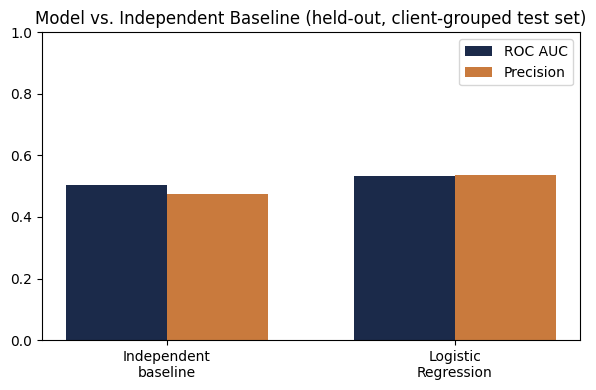

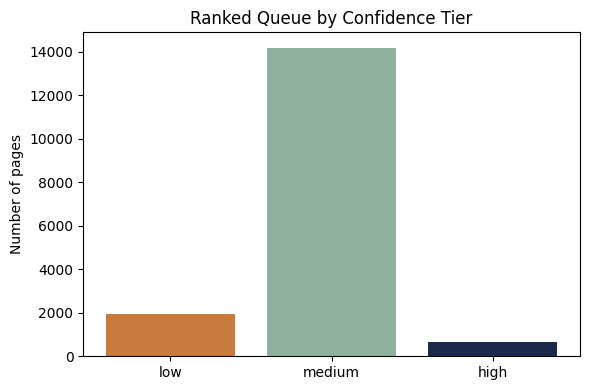

Saved: work/figures/model_vs_baseline.png
Saved: work/figures/confidence_tiers.png
Saved: work/outputs/capstone_top20_queue.csv
Saved: work/outputs/capstone_metrics.json


In [11]:
import matplotlib.pyplot as plt

os.makedirs('work/figures', exist_ok=True)
os.makedirs('work/outputs', exist_ok=True)

# Chart 1: Model vs Baseline (bar chart)
fig, ax = plt.subplots(figsize=(6, 4))
methods = ['Independent\nbaseline', 'Logistic\nRegression']
auc_vals = [baseline_auc_independent, model_auc]
precision_vals = [baseline_precision_independent, model_precision]

x = np.arange(len(methods))
width = 0.35
ax.bar(x - width/2, auc_vals, width, label='ROC AUC', color='#1B2A4A')
ax.bar(x + width/2, precision_vals, width, label='Precision', color='#C97A3D')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 1)
ax.set_title('Model vs. Independent Baseline (held-out, client-grouped test set)')
ax.legend()
plt.tight_layout()
plt.savefig('work/figures/model_vs_baseline.png', dpi=150)
plt.show()

# Chart 2: Confidence tier distribution
fig, ax = plt.subplots(figsize=(6, 4))
tier_counts = ranked_queue['confidence_tier'].value_counts().reindex(['low', 'medium', 'high'])
ax.bar(tier_counts.index, tier_counts.values, color=['#C97A3D', '#8FAF9F', '#1B2A4A'])
ax.set_title('Ranked Queue by Confidence Tier')
ax.set_ylabel('Number of pages')
plt.tight_layout()
plt.savefig('work/figures/confidence_tiers.png', dpi=150)
plt.show()

# Export the top 20 of the ranked queue as a table for the paper (public-safe: hashed IDs only)
paper_table = ranked_queue[['content_hash_id', 'model_probability', 'confidence_tier',
                              'reason_code', 'action']].head(20)
paper_table.to_csv('work/outputs/capstone_top20_queue.csv', index=False)

# Final metrics JSON — the paper's numbers trace back to this
capstone_metrics = {
    "lane": "Refresh / Content Opportunity Scoring",
    "data_slice": {"month": "2026-03", "total_rows": 9841378, "n_clients": 55, "n_content_items": 331437},
    "model": "Logistic Regression",
    "split_design": "grouped by client_hash_id, 0 overlap confirmed",
    "test_set_size": len(ranked_queue),
    "results": {
        "independent_baseline_auc": round(float(baseline_auc_independent), 3),
        "independent_baseline_precision": round(float(baseline_precision_independent), 3),
        "model_auc": round(float(model_auc), 3),
        "model_precision": round(float(model_precision), 3),
    },
    "confidence_tier_counts": tier_counts.to_dict(),
    "saturated_probability_rows": int(saturated),
    "known_limitations": [
        "single-month snapshot, feature/label window overlap",
        "client history depth not verified per dim_clients.gsc_data_start",
        "circular baseline (actual_ctr-based) found and excluded",
        "content_updated_date found unreliable and excluded"
    ]
}
with open('work/outputs/capstone_metrics.json', 'w') as f:
    json.dump(capstone_metrics, f, indent=2, default=str)

print("Saved: work/figures/model_vs_baseline.png")
print("Saved: work/figures/confidence_tiers.png")
print("Saved: work/outputs/capstone_top20_queue.csv")
print("Saved: work/outputs/capstone_metrics.json")

## ML-12 — Demo outline, social post, employer summary

### 5-minute demo outline

1. **(30s) The problem:** content teams can't manually review every page — show the
   scale (9.8M rows, 331K content items in one month alone for this slice).
2. **(60s) The baseline:** a simple, honest rule using only position and impression
   volume — show its modest 0.503 AUC.
3. **(90s) The model:** a Logistic Regression trained on the same signals, validated on
   clients it never saw — show the 0.532 AUC / 0.538 precision result, and name why the
   split matters (client leakage inflated an early version to 0.567).
4. **(60s) The honest catch:** walk through the circular-baseline discovery (0.996 AUC
   that turned out to be measuring the label against itself) — this is the moment that
   actually demonstrates the skill, not the model's win.
5. **(60s) The output:** show the ranked queue with reason codes and confidence tiers,
   and the disclosed client-concentration anomaly in the top 19 rows.
6. **(20s) Close:** this is decision-support, not automation — a human still reviews
   every flagged page.

### Social post cut

> Spent 8 weeks building an ML pipeline on 9.8M rows of real search performance data —
> and the most useful thing I found wasn't a great model, it was a bug in my own baseline.
> An early "89.6%→99.6% AUC" result turned out to be circular: I was measuring a metric
> against a label built from that same metric. Caught it, fixed it, and the honest number
> (0.532 AUC vs. a 0.503 baseline) is a real, if modest, result I can actually stand behind.
> Full writeup + reproducible repo: [paper URL] / [repo URL]

### 3-sentence employer-facing summary

I built and honestly validated a machine learning model that ranks website content pages
by how much their click-through rate underperforms expectation, using 9.8 million rows
of real search performance data across 55 clients. Along the way, I caught and corrected
two genuine methodology errors in my own analysis — a data field that silently leaked
future information, and a baseline comparison that was circular by construction — rather
than reporting inflated results. The final model modestly but measurably outperforms an
independent baseline (0.532 vs. 0.503 ROC AUC) on data from clients it never saw during
training, and produces a ranked, reason-coded action list designed for human review, not
automated action.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
